# IMU Dataset Exploration
Exploratory analysis of `parsed_30gigs/DIP_IMU_train_real_imu_position_only` and `DIP_IMU_test_real_imu_position_only`.

## 1. Folder Structure & File Counts

In [1]:
import os
import glob
from pathlib import Path

BASE = Path('parsed_30gigs')
TRAIN_DIR = BASE / 'DIP_IMU_train_real_imu_position_only'
TEST_DIR  = BASE / 'DIP_IMU_test_real_imu_position_only'

for split, d in [('TRAIN', TRAIN_DIR), ('TEST', TEST_DIR)]:
    files = sorted(d.glob('*.pt'))
    total_bytes = sum(f.stat().st_size for f in files)
    print(f"{split}: {len(files)} files  |  {total_bytes / 1e9:.2f} GB")
    print(f"  First 5 : {[f.name for f in files[:5]]}")
    print(f"  Last  5 : {[f.name for f in files[-5:]]}")
    print()

TRAIN: 885 files  |  1.16 GB
  First 5 : ['s_01_01_seg0.pt', 's_01_01_seg1.pt', 's_01_01_seg10.pt', 's_01_01_seg11.pt', 's_01_01_seg12.pt']
  Last  5 : ['s_08_05_seg5.pt', 's_08_05_seg6.pt', 's_08_05_seg7.pt', 's_08_05_seg8.pt', 's_08_05_seg9.pt']

TEST: 19 files  |  0.25 GB
  First 5 : ['s_09_01_a.pt', 's_09_01_b.pt', 's_09_01_c.pt', 's_09_02_a.pt', 's_09_02_b.pt']
  Last  5 : ['s_10_03_b.pt', 's_10_04_a.pt', 's_10_04_b.pt', 's_10_04_c.pt', 's_10_05.pt']



## 2. Naming Convention Breakdown

In [2]:
import re
from collections import Counter

train_files = sorted(TRAIN_DIR.glob('*.pt'))
test_files  = sorted(TEST_DIR.glob('*.pt'))

# Count files per subject in training set
subject_counts = Counter()
for f in train_files:
    m = re.match(r's_(\d+)', f.stem)
    if m:
        subject_counts[f's_{m.group(1)}'] += 1

print('Train files per subject:')
for subj, count in sorted(subject_counts.items()):
    print(f'  {subj}: {count} files')

print()
print('Test files:')
for f in test_files:
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)')

Train files per subject:
  s_01: 116 files
  s_02: 111 files
  s_03: 114 files
  s_04: 105 files
  s_05: 115 files
  s_06: 114 files
  s_07: 104 files
  s_08: 106 files

Test files:
  s_09_01_a.pt  (20.8 MB)
  s_09_01_b.pt  (11.5 MB)
  s_09_01_c.pt  (9.3 MB)
  s_09_02_a.pt  (12.1 MB)
  s_09_02_b.pt  (11.2 MB)
  s_09_03_a.pt  (12.7 MB)
  s_09_03_b.pt  (13.2 MB)
  s_09_04.pt  (5.2 MB)
  s_09_05.pt  (19.8 MB)
  s_10_01_a.pt  (24.5 MB)
  s_10_01_b.pt  (14.5 MB)
  s_10_01_c.pt  (10.0 MB)
  s_10_02.pt  (15.8 MB)
  s_10_03_a.pt  (13.3 MB)
  s_10_03_b.pt  (16.4 MB)
  s_10_04_a.pt  (3.8 MB)
  s_10_04_b.pt  (6.6 MB)
  s_10_04_c.pt  (9.0 MB)
  s_10_05.pt  (23.7 MB)


In [18]:
SMPL_JOINT_NAMES = {
    0:  'pelvis',
    1:  'left_hip',
    2:  'right_hip',
    3:  'spine1',
    4:  'left_knee',
    5:  'right_knee',
    6:  'spine2',
    7:  'left_ankle',
    8:  'right_ankle',
    9:  'spine3',
    10: 'left_foot',
    11: 'right_foot',
    12: 'neck',
    13: 'left_collar',
    14: 'right_collar',
    15: 'head',
    16: 'left_shoulder',
    17: 'right_shoulder',
    18: 'left_elbow',
    19: 'right_elbow',
    20: 'left_wrist',
    21: 'right_wrist',
    22: 'left_hand',
    23: 'right_hand'
}

## 3. Inspect a Single Training File

In [3]:
import torch
import numpy as np

def inspect_file(path):
    """Load a .pt file and print shape/dtype/stats for every array."""
    data = torch.load(path, map_location='cpu', weights_only=False)
    print(f"File : {Path(path).name}")
    print(f"Type : {type(data).__name__}")
    print()

    def _show(key, val, indent=2):
        pad = ' ' * indent
        if isinstance(val, dict):
            print(f"{pad}{key}:")
            for k, v in val.items():
                _show(k, v, indent + 2)
        elif val is None:
            print(f"{pad}{key}: None")
        elif hasattr(val, 'shape'):
            arr = val.numpy() if isinstance(val, torch.Tensor) else val
            flat = arr.flatten().astype(np.float64)
            nan_count = int(np.isnan(flat).sum())
            inf_count = int(np.isinf(flat).sum())
            print(f"{pad}{key}:")
            print(f"{pad}  shape={tuple(val.shape)}  dtype={val.dtype}")
            print(f"{pad}  min={np.nanmin(flat):.4f}  max={np.nanmax(flat):.4f}  mean={np.nanmean(flat):.4f}")
            print(f"{pad}  NaN={nan_count}  Inf={inf_count}")
        else:
            print(f"{pad}{key}: {val}")

    if isinstance(data, dict):
        for k, v in data.items():
            _show(k, v)
    elif hasattr(data, 'shape'):
        _show('tensor', data)
    print()

inspect_file(TRAIN_DIR / 's_01_01_seg0.pt')

File : s_01_01_seg0.pt
Type : dict

  joint:
    orientation:
      shape=(300, 24, 3, 3)  dtype=torch.float32
      min=-0.9965  max=1.0000  mean=0.2565
      NaN=0  Inf=0
    velocity:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-1.2642  max=2.7316  mean=0.0081
      NaN=0  Inf=0
    position:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-0.9670  max=1.0664  mean=-0.0189
      NaN=0  Inf=0
    asp_position:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-0.9670  max=1.1544  mean=-0.0432
      NaN=0  Inf=0
    asp_velocity:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-1.5483  max=3.1306  mean=0.0122
      NaN=0  Inf=0
  imu:
    imu:
      shape=(300, 17, 9)  dtype=torch.float32
      min=-13.7062  max=21.2294  mean=0.1206
      NaN=0  Inf=0
  vimu:
    vimu_joints:
      shape=(300, 24, 9)  dtype=torch.float32
      min=-59.6631  max=48.5968  mean=0.1277
      NaN=0  Inf=0
    vimu_mesh: None
  gt:
    pose_local:
      shape=(300, 24, 3, 3

## 4. Inspect Files from Different Subjects / Sessions

In [4]:
sample_files = [
    TRAIN_DIR / 's_04_03_seg10.pt',
    TRAIN_DIR / 's_08_01_b_seg4.pt',
    TEST_DIR  / 's_09_01_a.pt',
    TEST_DIR  / 's_10_03_a.pt',
]

for f in sample_files:
    inspect_file(f)
    print('-' * 60)

File : s_04_03_seg10.pt
Type : dict

  joint:
    orientation:
      shape=(300, 24, 3, 3)  dtype=torch.float32
      min=-1.0000  max=1.0000  mean=0.1844
      NaN=0  Inf=0
    velocity:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-1.5209  max=2.3733  mean=0.0101
      NaN=0  Inf=0
    position:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-0.9639  max=0.6174  mean=-0.0115
      NaN=0  Inf=0
    asp_position:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-0.9673  max=0.8117  mean=-0.0417
      NaN=0  Inf=0
    asp_velocity:
      shape=(300, 24, 3)  dtype=torch.float32
      min=-1.5209  max=2.4614  mean=0.0168
      NaN=0  Inf=0
  imu:
    imu:
      shape=(300, 17, 9)  dtype=torch.float32
      min=-56.1604  max=46.5411  mean=0.1559
      NaN=0  Inf=0
  vimu:
    vimu_joints:
      shape=(300, 24, 9)  dtype=torch.float32
      min=-25.7398  max=32.5836  mean=0.1500
      NaN=0  Inf=0
    vimu_mesh: None
  gt:
    pose_local:
      shape=(300, 24, 3, 

## 5. Shape Consistency Check Across Training Files

In [5]:
def get_shapes(path):
    data = torch.load(path, map_location='cpu', weights_only=False)
    shapes = {}
    def _collect(prefix, val):
        if isinstance(val, dict):
            for k, v in val.items():
                _collect(f"{prefix}.{k}", v)
        elif hasattr(val, 'shape'):
            shapes[prefix] = tuple(val.shape)
        else:
            shapes[prefix] = None
    _collect('root', data)
    return shapes

# Check first 30 training files for shape consistency
reference = None
mismatches = []

for f in train_files[:30]:
    s = get_shapes(f)
    # Normalise time dimension to compare structure only
    schema = {k: v[1:] if (v and len(v) > 1) else v for k, v in s.items()}
    if reference is None:
        reference = schema
        print(f"Reference schema from {f.name}:")
        for k, v in s.items():
            print(f"  {k}: {v}")
        print()
    elif schema != reference:
        mismatches.append(f.name)

if mismatches:
    print(f"Schema mismatches found in: {mismatches}")
else:
    print(f"All 30 files share the same schema (time dimension excluded). Data is consistent.")

Reference schema from s_01_01_seg0.pt:
  root.joint.orientation: (300, 24, 3, 3)
  root.joint.velocity: (300, 24, 3)
  root.joint.position: (300, 24, 3)
  root.joint.asp_position: (300, 24, 3)
  root.joint.asp_velocity: (300, 24, 3)
  root.imu.imu: (300, 17, 9)
  root.vimu.vimu_joints: (300, 24, 9)
  root.vimu.vimu_mesh: None
  root.gt.pose_local: (300, 24, 3, 3)
  root.gt.tran: None
  root.gt.ft_contact: (300, 2)

All 30 files share the same schema (time dimension excluded). Data is consistent.


## 6. Time-Dimension Distribution

In [6]:
from collections import Counter

def get_T(path):
    data = torch.load(path, map_location='cpu', weights_only=False)
    # imu.imu is always present; grab its first dim
    return data['imu']['imu'].shape[0]

train_T = Counter(get_T(f) for f in train_files)
test_T  = {f.name: get_T(f) for f in test_files}

print('Training T distribution (frames per clip):')
for t, count in sorted(train_T.items()):
    print(f'  T={t}: {count} files')

print()
print('Test T per file:')
for name, t in test_T.items():
    fps = 30
    print(f'  {name}: T={t}  ({t/fps:.1f} sec @ {fps} Hz)')

Training T distribution (frames per clip):
  T=300: 885 files

Test T per file:
  s_09_01_a.pt: T=4757  (158.6 sec @ 30 Hz)
  s_09_01_b.pt: T=2641  (88.0 sec @ 30 Hz)
  s_09_01_c.pt: T=2136  (71.2 sec @ 30 Hz)
  s_09_02_a.pt: T=2767  (92.2 sec @ 30 Hz)
  s_09_02_b.pt: T=2559  (85.3 sec @ 30 Hz)
  s_09_03_a.pt: T=2907  (96.9 sec @ 30 Hz)
  s_09_03_b.pt: T=3015  (100.5 sec @ 30 Hz)
  s_09_04.pt: T=1188  (39.6 sec @ 30 Hz)
  s_09_05.pt: T=4539  (151.3 sec @ 30 Hz)
  s_10_01_a.pt: T=5609  (187.0 sec @ 30 Hz)
  s_10_01_b.pt: T=3330  (111.0 sec @ 30 Hz)
  s_10_01_c.pt: T=2284  (76.1 sec @ 30 Hz)
  s_10_02.pt: T=3619  (120.6 sec @ 30 Hz)
  s_10_03_a.pt: T=3038  (101.3 sec @ 30 Hz)
  s_10_03_b.pt: T=3751  (125.0 sec @ 30 Hz)
  s_10_04_a.pt: T=865  (28.8 sec @ 30 Hz)
  s_10_04_b.pt: T=1511  (50.4 sec @ 30 Hz)
  s_10_04_c.pt: T=2051  (68.4 sec @ 30 Hz)
  s_10_05.pt: T=5427  (180.9 sec @ 30 Hz)


## 7. Foot Contact Label Distribution

In [7]:
contact_stats = []

for f in train_files:
    data = torch.load(f, map_location='cpu', weights_only=False)
    fc = data['gt']['ft_contact'].numpy()  # [T, 2]
    contact_stats.append(fc.mean(axis=0))  # mean contact rate per foot

contact_stats = np.array(contact_stats)  # [N_files, 2]
print('Foot contact rate across training clips (0=never, 1=always):')
print(f'  Left foot  — mean: {contact_stats[:,0].mean():.3f}  std: {contact_stats[:,0].std():.3f}')
print(f'  Right foot — mean: {contact_stats[:,1].mean():.3f}  std: {contact_stats[:,1].std():.3f}')

Foot contact rate across training clips (0=never, 1=always):
  Left foot  — mean: 0.731  std: 0.341
  Right foot — mean: 0.732  std: 0.341


## 8. IMU Signal Statistics Across All Training Files

In [8]:
imu_mins, imu_maxs, imu_means = [], [], []

for f in train_files:
    data = torch.load(f, map_location='cpu', weights_only=False)
    imu = data['imu']['imu'].numpy().astype(np.float64)  # [T, 17, 9]
    imu_mins.append(imu.min())
    imu_maxs.append(imu.max())
    imu_means.append(imu.mean())

print('imu.imu statistics across all training files:')
print(f'  Global min  : {min(imu_mins):.4f}')
print(f'  Global max  : {max(imu_maxs):.4f}')
print(f'  Mean of means: {np.mean(imu_means):.4f}')

imu.imu statistics across all training files:
  Global min  : -137.6922
  Global max  : 138.6805
  Mean of means: 0.1213


## 9. Field Interpretation Summary

| Field | Shape | Dtype | Interpretation |
|---|---|---|---|
| `joint.orientation` | `[T, 24, 3, 3]` | float32 | Joint orientations as 3×3 rotation matrices (SO(3)) |
| `joint.position` | `[T, 24, 3]` | float32 | 3D world-space positions of 24 SMPL joints (metres) |
| `joint.velocity` | `[T, 24, 3]` | float32 | Time-derivative of position (m/s) |
| `joint.asp_position` | `[T, 24, 3]` | float32 | Smoothed / root-relative position variant |
| `joint.asp_velocity` | `[T, 24, 3]` | float32 | Corresponding smoothed velocity |
| `imu.imu` | `[T, 17, 9]` | float32 | 17 physical IMU sensors; 9 values = accel(3) + gyro(3) + mag/rot(3) |
| `vimu.vimu_joints` | `[T, 24, 9]` | float32 | Virtual IMU synthesised at each SMPL joint from mocap GT |
| `gt.pose_local` | `[T, 24, 3, 3]` | float32 | Ground-truth local rotation matrices per joint (model target) |
| `gt.tran` | None | — | Root translation not stored in this dataset variant |
| `gt.ft_contact` | `[T, 2]` | int32 | Binary foot contact: `[left, right]` (0=airborne, 1=contact) |

**Notes:**
- 24 joints → SMPL body model
- 17 IMU sensors → standard DIP-IMU body placement
- Training clips: T=300 (10 sec @ 30 Hz)
- Test sequences: T≈3000–5000 (full unsegmented sessions)

## 10. Signal Visualization — vimu.vimu_joints Acceleration Channels

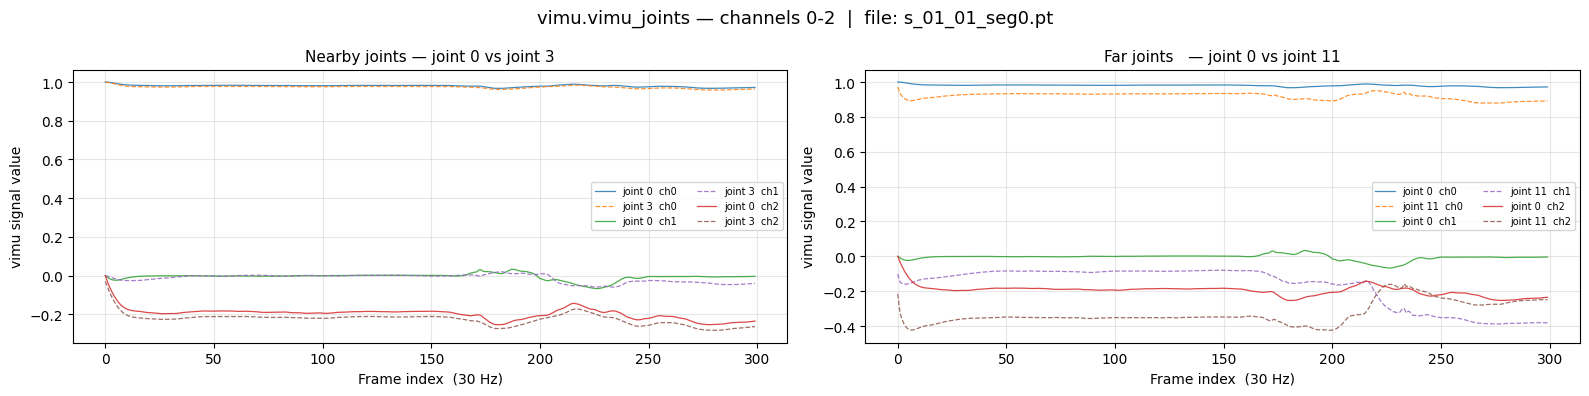

In [17]:
import matplotlib.pyplot as plt

data = torch.load(TRAIN_DIR / 's_01_01_seg0.pt', map_location='cpu', weights_only=False)
vimu = data['vimu']['vimu_joints'].numpy()  # [T, 24, 9]
# Channels 0-2 are the first 3 signal dimensions (acceleration-like)
T = vimu.shape[0]
t = np.arange(T)

pairs = [
    ('Nearby joints — joint 0 vs joint 3',   0,  3),
    ('Far joints   — joint 0 vs joint 11',   0, 11),
]
ch_colors_a = ['#1f77b4', '#2ca02c', '#d62728']
ch_colors_b = ['#ff7f0e', '#9467bd', '#8c564b']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('vimu.vimu_joints — channels 0-2  |  file: s_01_01_seg0.pt', fontsize=13)

for ax, (title, j_a, j_b) in zip(axes, pairs):
    for c in range(3):
        ax.plot(t, vimu[:, j_a, c], color=ch_colors_a[c], alpha=0.85,
                linewidth=0.9, label=f'joint {j_a}  ch{c}')
        ax.plot(t, vimu[:, j_b, c], color=ch_colors_b[c], alpha=0.85,
                linewidth=0.9, linestyle='--', label=f'joint {j_b}  ch{c}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Frame index  (30 Hz)')
    ax.set_ylabel('vimu signal value')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Activity and Subject Diversity

In [12]:
from collections import defaultdict

# Parse subject ID and session ID from filename stems
# Pattern: s_XX_YY[_variant][_segN]
subject_sessions = defaultdict(set)
subject_file_counts = defaultdict(int)

for f in train_files:
    stem = f.stem
    m = re.match(r's_(\d+)_(\d+)', stem)
    if m:
        subj = int(m.group(1))
        sess = int(m.group(2))
        subject_sessions[subj].add(sess)
        subject_file_counts[subj] += 1

print(f"{'Subject':<10} {'Unique Sessions':<18} {'Session IDs':<25} {'# Files'}")
print('-' * 65)
total_files = 0
for subj in sorted(subject_sessions.keys()):
    sessions = sorted(subject_sessions[subj])
    n_files  = subject_file_counts[subj]
    total_files += n_files
    print(f"  s_{subj:02d}    {len(sessions):<18} {str(sessions):<25} {n_files}")

print('-' * 65)
print(f"{'TOTAL':<10} {'':<18} {'':<25} {total_files}")
print()
print(f"Unique subjects : {len(subject_sessions)}")
print(f"Total sessions  : {sum(len(v) for v in subject_sessions.values())}  (across all subjects)")

Subject    Unique Sessions    Session IDs               # Files
-----------------------------------------------------------------
  s_01    5                  [1, 2, 3, 4, 5]           116
  s_02    5                  [1, 2, 3, 4, 5]           111
  s_03    4                  [1, 3, 4, 5]              114
  s_04    5                  [1, 2, 3, 4, 5]           105
  s_05    5                  [1, 2, 3, 4, 5]           115
  s_06    5                  [1, 2, 3, 4, 5]           114
  s_07    5                  [1, 2, 3, 4, 5]           104
  s_08    5                  [1, 2, 3, 4, 5]           106
-----------------------------------------------------------------
TOTAL                                                   885

Unique subjects : 8
Total sessions  : 39  (across all subjects)


## 12. Verify T=300 Across All Training Files

In [13]:
all_T = []
deviations = []

for f in train_files:
    data = torch.load(f, map_location='cpu', weights_only=False)
    t_val = data['vimu']['vimu_joints'].shape[0]
    all_T.append(t_val)
    if t_val != 300:
        deviations.append((f.name, t_val))

all_T = np.array(all_T)
print(f"Checked {len(all_T)} training files  (vimu.vimu_joints T dimension)")
print()
print(f"  min T  : {all_T.min()}")
print(f"  max T  : {all_T.max()}")
print(f"  mean T : {all_T.mean():.2f}")
print(f"  std  T : {all_T.std():.4f}")
print()
if deviations:
    print(f"Files deviating from T=300 ({len(deviations)} total):")
    for name, t in deviations:
        print(f"  {name}  T={t}")
else:
    print("All 885 files have exactly T=300. No deviations.")

Checked 885 training files  (vimu.vimu_joints T dimension)

  min T  : 300
  max T  : 300
  mean T : 300.00
  std  T : 0.0000

All 885 files have exactly T=300. No deviations.


## 13. Joint Positions Inspection — Frame 0 Skeleton Layout

joint.position  —  frame 0  (shape (24, 3))
 Joint           x           y           z
------------------------------------------
  [ 0]      0.00000      0.00000      0.00000
  [ 1]      0.05858     -0.08228     -0.01766
  [ 2]     -0.06031     -0.09051     -0.01354
  [ 3]      0.00444      0.12440     -0.03839
  [ 4]      0.07853     -0.47076     -0.01714
  [ 5]     -0.08857     -0.47562     -0.01609
  [ 6]      0.00958      0.26387     -0.02121
  [ 7]      0.03486     -0.89533     -0.05800
  [ 8]     -0.05280     -0.89430     -0.05377
  [ 9]      0.00718      0.31993     -0.02337
  [10]      0.07891     -0.95515      0.06323
  [11]     -0.06239     -0.96314      0.07747
  [12]     -0.00538      0.52951     -0.06817
  [13]      0.07930      0.43311     -0.04530
  [14]     -0.07504      0.43068     -0.05604
  [15]      0.00729      0.61925     -0.01981
  [16]      0.21090      0.43296     -0.05940
  [17]     -0.19711      0.43410     -0.06928
  [18]      0.22121      0.17661     -0.07

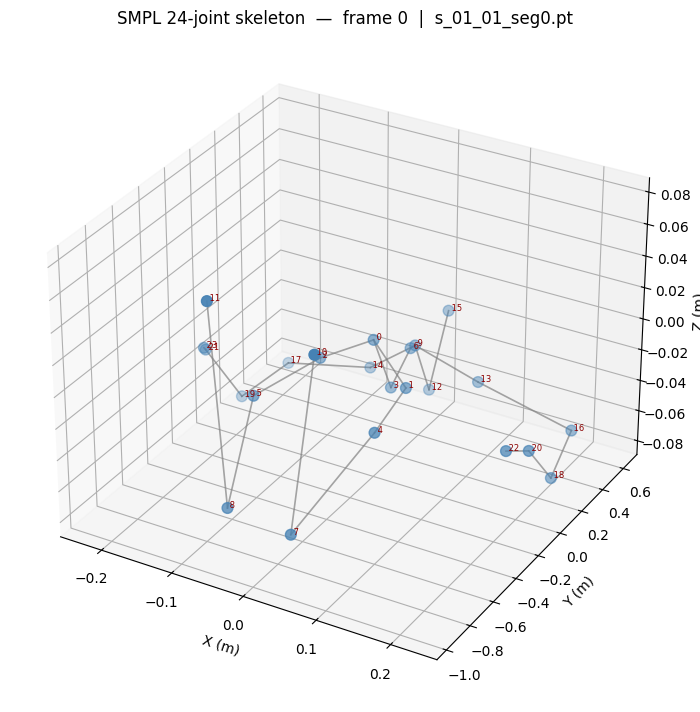

In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

data  = torch.load(TRAIN_DIR / 's_01_01_seg0.pt', map_location='cpu', weights_only=False)
pos   = data['joint']['position'].numpy()   # [T, 24, 3]
frame = pos[0]                               # [24, 3]  — first frame only

# ── Print table ────────────────────────────────────────────────
print(f"joint.position  —  frame 0  (shape {frame.shape})")
print(f"{'Joint':>6}  {'x':>10}  {'y':>10}  {'z':>10}")
print('-' * 42)
for i, (x, y, z) in enumerate(frame):
    print(f"  [{i:2d}]   {x:10.5f}   {y:10.5f}   {z:10.5f}")

# ── 3-D scatter plot ────────────────────────────────────────────
# SMPL joint connectivity (parent → child) — standard 24-joint skeleton
SMPL_PARENTS = [-1, 0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 9, 9,
                12, 13, 14, 16, 17, 18, 19, 20, 21]

fig = plt.figure(figsize=(7, 9))
ax  = fig.add_subplot(111, projection='3d')

xs, ys, zs = frame[:, 0], frame[:, 1], frame[:, 2]
ax.scatter(xs, ys, zs, c='steelblue', s=60, zorder=5)

for j, parent in enumerate(SMPL_PARENTS):
    if parent == -1:
        continue
    ax.plot([xs[j], xs[parent]],
            [ys[j], ys[parent]],
            [zs[j], zs[parent]],
            color='gray', linewidth=1.2, alpha=0.7)

for i, (x, y, z) in enumerate(frame):
    ax.text(x, y, z, f' {i}', fontsize=6, color='darkred')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('SMPL 24-joint skeleton  —  frame 0  |  s_01_01_seg0.pt')
plt.tight_layout()
plt.show()